# Ricerca di Trading System

Serve a **scoprire se un segnale di ingresso ha un vantaggio reale**, separando entry, uscita e "quando sto fermo" — cercarli insieme confonde quale dei tre sta davvero funzionando.

Si legge dall'alto in basso, senza celle facoltative: ogni sezione usa il risultato di quella prima.

**Ordine:** la Sessione 1 misura il segnale puro (nessun capitale, nessuna posizione). La Sessione 2 sceglie come uscirne e diventa un sistema vero, con trade e costi.

In [1]:
!pip install -q TA-Lib backtesting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.8/190.8 kB 8.4 MB/s eta 0:00:00


### Sezione 0 · Preparazione

Clona la repo e prepara l'ambiente. Va eseguita una volta sola a inizio sessione Colab.

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
from pathlib import Path
from google.colab import userdata
import shutil
# Salva il token una volta in Colab: icona chiave a sinistra → "Secrets" → aggiungi GITHUB_TOKEN
# Assicurati che il nome del secret sia 'GITHUB_TOKEN' (o quello che preferisci) e non il token stesso.
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

REPO_DIR = Path('/content/Trading-System-Creator_V4')
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)  # ripulisce il tentativo fallito precedente

!git clone https://{GITHUB_TOKEN}@github.com/matti410/Trading-System-Creator_V4.git

%cd Trading-System-Creator_V4

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Cloning into 'Trading-System-Creator_V4'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (168/168), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 168 (delta 84), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (168/168), 8.08 MiB | 5.19 MiB/s, done.
Resolving deltas: 100% (84/84), done.
/content/Trading-System-Creator_V4


In [3]:
import datetime as dt
from dateutil.relativedelta import relativedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import talib as ta

import entry_long, entry_short
import exit_long, exit_short
import engine as eng
from engine.vwap_ops import vwap_anchored_daily
import engine.event_study
import engine.splitting
from engine.exit_search_bt import run_exit_search_bt
import filter_conditions, vwap_regime_filter_conditions
from engine.filter_search_bt import run_filter_search_bt
from engine.due_meta import due_meta
from engine.equity_plot import plot_equity
from engine.costi import (parametri_backtest, verifica_da_storico_deals,
                          deriva_costo_nel_tempo, spread_corrente)
from engine.giudizio import scheda_strategia, soglia_rumore


/usr/local/lib/python3.13/dist-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


## Sezione 1 · I dati

Scarica le candele da MetaTrader 5.

**Parametri che puoi cambiare:** strumento, timeframe, periodo storico.

In [4]:
symbol    = "EURUSD"
timeframe = 'M15'
FREQ      = "15min"      # come pandas scrive il timeframe: "15min", "h", "D"

df = pd.read_csv('EURUSD_M15.csv', index_col='Date')
df.index = pd.to_datetime(df.index, utc=True)

print(f"{symbol} {timeframe} — {len(df):,} barre  ·  da {df.index[0]}  a  {df.index[-1]}")
df.tail(3)

EURUSD M15 — 167,219 barre  ·  da 2020-01-02 00:00:00+00:00  a  2026-09-18 23:30:00+00:00


,Open,High,Low,Close,Volume,spread
Date,,,,,,
2026-09-18 23:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,0
2026-09-18 23:15:00+00:00,1.14876,1.14890,1.14868,1.14880,262,0
2026-09-18 23:30:00+00:00,1.14880,1.14885,1.14846,1.14857,182,0


In [5]:
costi = parametri_backtest(symbol, bars=df, valuta_conto="USD", percentile=75.0, usa_mt5 = False, spread_pips = 0.1,)
costi   # -> {'spread': ..., 'commission': ...}

EURUSD  [forex]  conto in USD
   prezzo mediano   : 1.11191   nozionale: 111,191 USD
   spread           :  0.090 bp   <- listino (0.1 pips) — senza MT5
   commissione      :  0.630 bp   <- 7.00 USD round-turn per lotto
   COSTO ROUND-TURN :  0.719 bp
   -> spread=8.994e-06   commission=3.148e-05   (commission e' PER LATO: round-turn / 2)
   -> in pips: spread 0.100 + commissione 0.700 = 0.800 pips round-turn


{'spread': 8.99353364930615e-06, 'commission': 3.147736777257152e-05}

## Sezione 2 · Gli indicatori

Le condizioni di ingresso (`entry_long.py`, `entry_short.py`) non calcolano niente da sole: leggono colonne già pronte in questa tabella. Qui le costruiamo.

| Colonna | Cos'è | Chi la usa |
|---|---|---|
| `rsi` | oscillatore 0-100: sotto 30 il prezzo è "sceso troppo", sopra 70 "salito troppo" | l'entry mean reversion |
| `ema20`, `ema50` | medie mobili veloce e lenta | l'entry di controllo |
| `zlema50` | media mobile a ritardo ridotto | l'entry di trend |
| `atr`, `realized_vol` | quanto si muove il prezzo di solito | dimensionamento futuro |
| `vwap` | prezzo medio della giornata pesato per volume | i filtri di contesto |

Sulla **zero-lag EMA**: una media normale è sempre in ritardo; la ZLEMA lo compensa proiettando in avanti il prezzo, ma esagera i movimenti e genera più falsi attraversamenti — su M15 va bene (più campioni), ma è dove i costi di transazione pesano di più.

In [6]:
df["rsi"] = ta.RSI(df["Close"], timeperiod=14)
df['macd'], df['macd_signal'], df['macd_hist'] = ta.MACD(df["Close"], fastperiod=12, slowperiod=26, signalperiod=9)
df["ema20"] = df["Close"].ewm(span=20, min_periods=20).mean()   # ← min_periods
df["ema50"] = df["Close"].ewm(span=50, min_periods=50).mean()   # ← min_periods
def zlema(series, period):
    """Media mobile a ritardo ridotto: proietta il prezzo per compensare il lag."""
    lag = int((period - 1) / 2)
    return (2 * series - series.shift(lag)).ewm(span=period, adjust=False).mean()

df["zlema50"] = zlema(df["Close"], 50)
df["atr"] = ta.ATR(df["High"], df["Low"], df["Close"], timeperiod=14)          # ← ATR vero
df["realized_vol"] = df["Close"].pct_change().rolling(96).std()
df["adx"] = ta.ADX(df["High"], df["Low"], df["Close"], timeperiod=14)          # ← ADX vero
df["vwap"] = vwap_anchored_daily(df)
df.dropna(inplace=True)
print(f"{len(df):,} barre pronte, {df.shape[1]} colonne")
print(f"adx  — min {df['adx'].min():.1f}  mediana {df['adx'].median():.1f}  max {df['adx'].max():.1f}")
print(f"atr  — mediana {df['atr'].median():.6f}  ({df['atr'].median()/df['Close'].median()*100:.3f}% del prezzo)")
df.tail(3)

167,123 barre pronte, 17 colonne
adx  — min 5.3  mediana 22.7  max 79.8
atr  — mediana 0.000612  (0.055% del prezzo)


,Open,High,Low,Close,Volume,spread,rsi,macd,macd_signal,macd_hist,ema20,ema50,zlema50,atr,realized_vol,adx,vwap
Date,,,,,,,,,,,,,,,,,
2026-09-18 23:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,0,66.415834,0.000452,0.000363,0.000089,1.148023,1.147681,1.147956,0.000394,0.000255,29.515345,1.147537
2026-09-18 23:15:00+00:00,1.14876,1.14890,1.14868,1.14880,262,0,66.898341,0.000456,0.000382,0.000074,1.148097,1.147725,1.148093,0.000382,0.000255,30.520854,1.147544
2026-09-18 23:30:00+00:00,1.14880,1.14885,1.14846,1.14857,182,0,61.432928,0.000436,0.000392,0.000043,1.148142,1.147758,1.148198,0.000382,0.000256,30.468017,1.147548


## Sezione 3 · Dividere i dati in due

Questa è la regola più importante del notebook, e l'unica che non si può violare.

- **In-Sample (80%)** — la parte su cui si cerca, si prova, si sbaglia quante volte si vuole
- **Out-of-Sample (20%)** — la parte che **non si guarda fino alla fine**

Perché conta: su mille combinazioni provate, qualcuna sembrerà eccellente per puro caso — è garantito, anche su dati casuali. L'unico modo per accorgersene è tenere da parte dati che nessuna combinazione ha mai visto.

Se la guardi, cambi qualcosa e riguardi, l'Out-of-Sample non esiste più: è diventata parte della ricerca. **Si apre una volta sola, a ricerca in-sample conclusa** (passo 6 di `ROADMAP_RICERCA.md`).

In [7]:
IS_RATIO = 0.8
df_is, df_oos = eng.splitting.split_is_oos(df, is_ratio=IS_RATIO)
eng.splitting.describe_split(df_is, df_oos)

,n_barre,quota,dal,al
In-Sample,133698,0.799998,2020-01-03 00:00:00+00:00,2025-05-16 17:15:00+00:00
Out-of-Sample,33425,0.200002,2025-05-16 17:30:00+00:00,2026-09-18 23:30:00+00:00
Totale,167123,1.000000,2020-01-03 00:00:00+00:00,2026-09-18 23:30:00+00:00


## Sezione 4 · Features Engineering

Registra tutti i trigger di ingresso ed uscita nel registro condiviso — va fatto prima di qualunque uso di `event_study` o `exit_search_bt`, che leggono le entry da lì.

In [8]:
entry_long.registra_trigger_long()
entry_short.registra_trigger_short()

exit_long.registra_exit_long()
exit_short.registra_exit_short()

filter_conditions.registra_filtri()
vwap_regime_filter_conditions.registra_filtri_vwap()

[registra_trigger_long] 26 entry long registrate (0 gia' presenti).
[registra_trigger_short] 26 entry short registrate (0 gia' presenti).
[registra_exit_long] 4 exit long registrate (0 gia' presenti).
[registra_exit_short] 4 exit short registrate (0 gia' presenti).
[registra_filtri] 20 filtri registrati (0 gia' presenti).
[registra_filtri_vwap] 5 filtri registrati (0 gia' presenti).


## SESSIONE 1 · L'andamento del prezzo dopo il trigger

Per ogni condizione: tutte le barre in cui è vera, e dove va il prezzo dopo, fino all'orizzonte `H`. Si entra all'apertura della barra successiva al segnale (mai sullo stesso Close che l'ha generato). La curva è sempre "a favore del trade": per una condizione short, sale quando il prezzo scende.

`H` è una scelta, non una griglia: si calcola una volta sola e tutti gli orizzonti più corti si leggono sulla stessa curva.

**Nessuna occorrenza viene scartata**, nemmeno quelle scattate mentre si era già dentro un trade: contano tutte come eventi indipendenti.

## 1.1 · Le curve a confronto

Ogni linea è una condizione, asse orizzontale le barre dal trigger, verticale la variazione media in percentuale. **La linea nera tratteggiata è il mercato** (nessuna condizione): il metro di paragone — sopra di lei la curva aggiunge qualcosa, appiccicata a lei non dice niente.

Guarda la **forma**: sale e prosegue = il movimento continua; sale e si appiattisce = il vantaggio ha una scadenza (è lì l'orizzonte del trade); sale e ridiscende = quello che guadagnavi lo restituisci.

In [9]:
H = 25
MIN_TRADES = 200

pip = 0.0001 unita' di prezzo  (prezzo medio 1.11)
4 entry scartate sotto min_trades=200
  barra   3/25
  barra   6/25
  barra   9/25
  barra  12/25
  barra  15/25
  barra  18/25
  barra  21/25
  barra  24/25
  barra  25/25

48 entry · orizzonte 25 barre · 177,440 trigger misurati


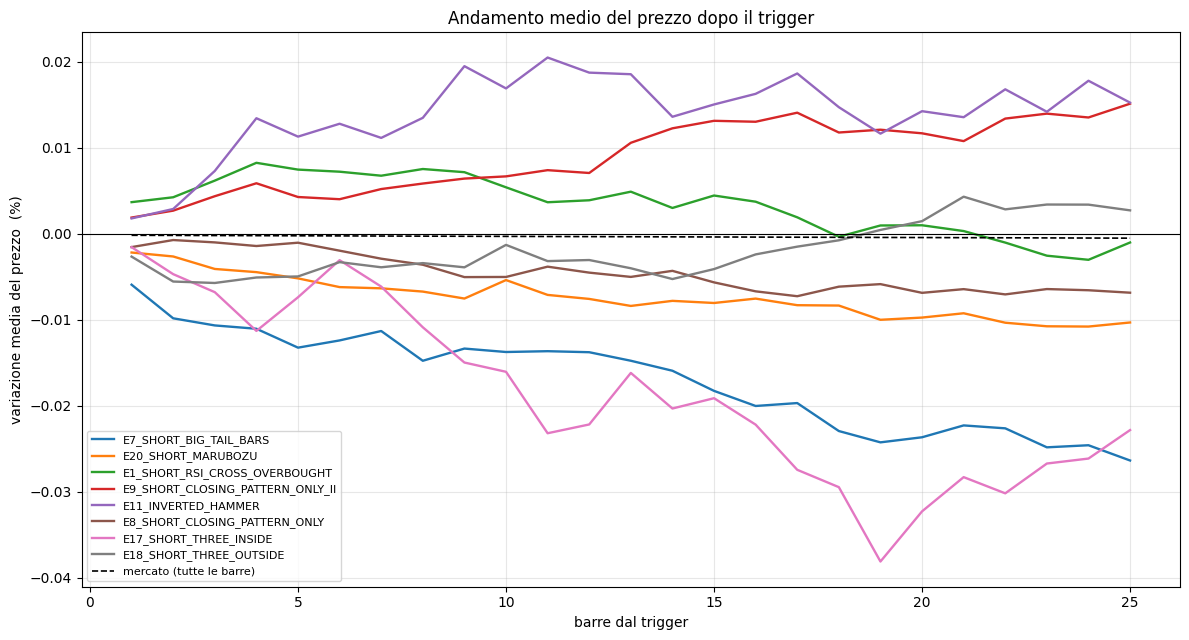

In [10]:
ev = eng.event_study.run_event_study(df_is, horizon=H, min_trades=MIN_TRADES)
ev.plot()
#ev.plot_singola("E7_BIG_TAIL_BARS", pips=True)

## 1.2 · La sintesi
| colonna | cosa dice |
|---|---|
| `trades` | quante volte la condizione è scattata |
| `barra_picco` / `barra_picco_netto` | dove la curva è più estrema, e dove si stacca di più dal mercato (usato da `diagnosi()`) |
| `picco_pct` / `picco_pips` | il valore a quel picco — **può essere negativo**: non è un errore, è un trade che perde |
| `incertezza_pct` | quanto balla la media a quel punto (errore standard) |
| `volte_incertezza` | picco diviso incertezza — sotto 2 il picco non si distingue dal rumore |
| `a_fine_pct` | dove sta il prezzo a fine orizzonte: più basso del picco = il movimento è rientrato |
| `vs_mercato_pct` | quanto il trigger si stacca dal movimento che il mercato fa comunque — vicino a zero = è il respiro dell'asset, non il segnale |
| `picco_in_coda` | `True` = il picco netto cade nell'ultimo quarto della finestra, segno di deriva casuale |


ordinata per ampiezza, non per solidità: guarda sempre trades e volte_incertezza prima di scegliere

In [11]:
ev.sintesi.round(4).sort_values('picco_pips', ascending=False).head(5)

,candidato,direction,trades,barra_picco,picco_pips,picco_pct,incertezza_pct,volte_incertezza,a_fine_pct,vs_mercato_pct,barra_picco_netto,picco_in_coda
4,E11_INVERTED_HAMMER,1,442,11,2.2593,0.0205,0.0078,2.6404,0.0153,0.0202,11,False
3,E9_SHORT_CLOSING_PATTERN_ONLY_II,-1,2087,25,1.6767,0.0152,0.0055,2.7466,0.0152,0.0156,25,True
9,E1_RSI_CROSS_OVERSOLD,1,1824,25,1.6330,0.0148,0.0065,2.2944,0.0148,0.0143,25,True
25,E7_BIG_TAIL_BARS,1,1061,25,1.2580,0.0114,0.0078,1.4522,0.0114,0.0109,25,True
26,E18_THREE_OUTSIDE,1,1279,22,1.0747,0.0098,0.0072,1.3613,0.0038,0.0093,22,True


### LONG side

In [12]:
ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips', 'picco_pct']].sort_values('picco_pips', ascending=False).head(6)

,candidato,picco_pips,picco_pct
4,E11_INVERTED_HAMMER,2.259293,0.020518
9,E1_RSI_CROSS_OVERSOLD,1.632999,0.014801
25,E7_BIG_TAIL_BARS,1.258023,0.011365
26,E18_THREE_OUTSIDE,1.074672,0.009793
35,E6_BACK_IN_STYLE,0.827157,0.007482
43,E11_INVERTED_HAMMER_CONFIRMED,0.788157,0.007149


### SHORT side

In [13]:
ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips', 'picco_pct']].sort_values('picco_pips', ascending=False).head(6)

,candidato,picco_pips,picco_pct
3,E9_SHORT_CLOSING_PATTERN_ONLY_II,1.676659,0.015150
32,E4_SHORT_EMA_CROSS_DOWN,0.984461,0.008908
2,E1_SHORT_RSI_CROSS_OVERBOUGHT,0.916683,0.008273
10,E3_SHORT_INTRABAR_STRENGTH_FADE,0.426390,0.003853
45,E10_SHORT_HANGING_MAN,0.338366,0.003051
42,E13_SHORT_HARAMI,0.242505,0.002188


In [14]:
ev.diagnosi()

orizzonte impostato          : 25 barre
picchi (netti) nell'ultimo quarto: 50% (24/48, oltre la barra 19)
|picco| / incertezza, mediana: 1.48
|picco| / incertezza, massimo: 3.22

I picchi si ammassano in fondo alla finestra: e' il
comportamento di una deriva casuale, non di un segnale.
Prova a rileggere con horizon=6
e guarda se la forma delle curve cambia.


# SESSIONE 2 · Le condizioni di uscita

Fin qui abbiamo **misurato** un segnale: nessun capitale, nessuna posizione, nessun costo. Da adesso costruiamo un **sistema**: si sceglie un ingresso e si cerca il modo di uscirne.

## 2.1 · Come vengono calcolati stop e target

Nessuna soglia scritta a mano: uno stop dello 0.15% è enorme su EURUSD e minuscolo su BTCUSD. Per ogni barra si misura quanto sarebbe andato in rosso e in verde un trade lì aperto e tenuto `n` barre; lo stop del trade che apri ora è il **percentile richiesto di quelle escursioni sulle ultime 500 occorrenze concluse** — si allarga da solo su un asset volatile, si stringe quando il mercato si calma. Il valore si fissa all'apertura e non cambia più.

> **Perché "concluse" e non "partite".** L'escursione di un trade aperto alla barra `i` si conosce solo alla `i+n`. Usare le ultime 500 partite userebbe prezzi futuri per uno stop deciso oggi — la finestra è quindi spostata indietro di `n` barre.


## 2.2 · Backtest con i trigger selezionati

Una riga per combinazione. `combinazione` si legge `L=<entry long> · S=<entry short>`
(`—` dove quel lato non ha ingresso). Sotto `min_trades` le righe spariscono: se una
combinazione attesa non c'è, controlla prima lì.

| colonna | cosa guardi |
|---|---|
| `avg_trade_netto` | **il numero che conta**: pips medi per trade al netto delle commissioni. Sopra zero o non se ne parla |
| `avg_trade` | lo stesso, lordo — serve solo a vedere quanto si mangiano i costi |
| `trades` | sotto il centinaio, qualunque numero è rumore |
| `sharpe`, `max_dd_pct`, `win_rate_pct`, `profit_factor` | contorno |

**Cosa fai dopo:** scegli la combinazione con `avg_trade_netto` più alto e abbastanza
trade, e congelala. In una chiamata l'uscita è identica per tutte le righe: la tabella
dice *quale entry rende di più con QUESTA uscita*, non quale uscita è la migliore.
Per confrontare uscite diverse rilanci con altri valori.

**TEST 1**

Condizioni di uscita: STOP LOSS, TAKE PROFIT

In [15]:
es = run_exit_search_bt(df_is, entry_cols_long=["E11_INVERTED_HAMMER", None],
                        entry_cols_short=["E9_SHORT_CLOSING_PATTERN_ONLY_II", None],
                        n_barre=H, perc_sl=90.0, perc_tp=0.0,
                        **costi,)
es.top(10)
#es.trades("L=E7_BIG_TAIL_BARS · S=E9_SHORT_CLOSING_PATTERN_ONLY_II")

1 combinazione/i (None, None, *) scartata/e: nessun ingresso.
segnali ignorati per soglia non calcolabile — E9_SHORT_CLOSING_PATTERN_ONLY_II: 12


Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

3 combinazioni · n_barre=25 · coppie di uscita: ['—'] · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00001 · commission 0.00003 · margin 1.0


,combinazione,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,avg_trade_netto,durata_media,durata_max
0,L=— · S=E9_SHORT_CLOSING_PATTERN_ONLY_II | X=—,1594,10.111,0.428,-5.977,49.310,1.076,1.426,0.729,23.658,25
1,L=E11_INVERTED_HAMMER · S=E9_SHORT_CLOSING_PAT...,1797,9.068,0.362,-8.603,49.026,1.061,1.272,0.576,23.714,25
2,L=E11_INVERTED_HAMMER · S=— | X=—,404,0.422,0.038,-5.164,48.020,1.016,0.866,0.172,24.131,25


**TEST 2**

Condizioni di uscita: STOP LOSS, TAKE PROFIT, Regole meccaniche

In [16]:
es = run_exit_search_bt(df_is,
                        entry_cols_long=["E11_INVERTED_HAMMER"],
                        entry_cols_short=["E9_SHORT_CLOSING_PATTERN_ONLY_II"],
                        n_barre=H,
                        exit_rule_pairs=["RSI_EXTREME", "MACD_CROSS",
                                         "EMA_CROSS", None],
                        perc_sl=90.0, perc_tp=0.0, **costi,
                        min_trades=30,)
es.top(10)

segnali ignorati per soglia non calcolabile — E9_SHORT_CLOSING_PATTERN_ONLY_II: 12


Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

4 combinazioni · n_barre=25 · coppie di uscita: ['RSI_EXTREME', 'MACD_CROSS', 'EMA_CROSS', '—'] · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00001 · commission 0.00003 · margin 1.0


,combinazione,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,avg_trade_netto,durata_media,durata_max
0,L=E11_INVERTED_HAMMER · S=E9_SHORT_CLOSING_PAT...,1854,14.049,0.569,-7.040,51.241,1.091,1.515,0.818,21.482,25
1,L=E11_INVERTED_HAMMER · S=E9_SHORT_CLOSING_PAT...,1797,9.068,0.362,-8.603,49.026,1.061,1.272,0.576,23.714,25
2,L=E11_INVERTED_HAMMER · S=E9_SHORT_CLOSING_PAT...,2208,-5.199,-0.333,-12.110,42.935,0.947,0.469,-0.227,8.948,25
3,L=E11_INVERTED_HAMMER · S=E9_SHORT_CLOSING_PAT...,2413,-11.057,-1.106,-11.986,39.039,0.826,0.170,-0.526,3.817,25


## 3.1 · La classifica

Baseline (nessun filtro) + una riga per filtro, ordinata per `t_guadagno`.

| colonna | cosa guardi |
|---|---|
| `t_guadagno` | **la colonna che decide**: i trade che il filtro TIENE battono quelli che SCARTA, e di quanto rispetto al rumore |
| `oltre_rumore` | `True` solo se `t_guadagno` supera la soglia stampata sopra la tabella |
| `guadagno_pips` | di quanto li battono, in pips — la dimensione economica |
| `esito` | `SCARTATA` · `CAMPIONE CORTO` · `DA VALUTARE` |
| `motivo` | quale criterio è caduto |
| `avg_trade_netto`, `t_stat`, `p_ev_neg` | il sistema filtrato preso da solo |

**La soglia di rumore.** Provando 17 filtri, il migliore dei 17 sembra buono anche su
dati casuali. La riga stampata sopra la tabella dice oltre quale `|t_guadagno|` il
risultato non è più spiegabile dal caso. Conta solo le prove di *questa* chiamata:
è un pavimento, non un tetto.

**Cosa fai dopo:** vanno a `due_meta` solo le righe che NON sono `SCARTATA`.
Se non ce n'è nessuna, la risposta è che questa famiglia di filtri non aggiunge
niente: si torna indietro, non si abbassa la soglia.

`guadagno_sharpe` resta in `fs.risultati` come riferimento. Non decide più —
è uno Sharpe di equity giornaliera, quindi dipende da quanti trade fai e da quanto
stai a mercato, non solo dalla qualità del vantaggio.

In [17]:
filtri_da_provare = (eng.registry.list_filters(0) +
                     eng.registry.list_filters(1) +
                     eng.registry.list_filters(-1))

In [18]:
fs = run_filter_search_bt(
    df_is,
    entry_long="E11_INVERTED_HAMMER",
    entry_short="E9_SHORT_CLOSING_PATTERN_ONLY_II",
    exit_rule_pair="RSI_EXTREME",
    n_barre=H,
    filtri=filtri_da_provare,
    perc_sl=90.0, perc_tp=0.0, **costi, min_trades_giudizio=100,
    p_max=5.0, alpha=0.05
)
fs.top(20)

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

18 righe (baseline + 17 filtri/coppie) · n_barre=25 · exit_rule_pair=RSI_EXTREME · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00001 · commission 0.00003 · margin 1.0
soglia di rumore per 17 prove (Sidak, famiglia 5%): |t_guadagno| > 2.97  —  conta solo le prove di questa chiamata, e' un pavimento


,filtro,trades,avg_trade_netto,t_stat,p_ev_neg,guadagno_pips,t_guadagno,oltre_rumore,esito,motivo
0,F3_VOLUME_ABOVE_AVG,1008,1.430,1.651,4.79,1.684,1.446,False,SCARTATA,|t| 1.45 < soglia rumore 2.97
1,VWAP_GAP_WIDENING,1257,1.568,2.150,1.81,1.372,1.194,False,SCARTATA,|t| 1.19 < soglia rumore 2.97
2,F6_VOLUME_ABOVE_AVG_50,984,1.361,1.475,7.20,1.319,1.137,False,SCARTATA,|t| 1.14 < soglia rumore 2.97
3,F15_SHORT_TERM_CONSISTENCY,1027,1.465,1.888,2.96,1.285,1.122,False,SCARTATA,|t| 1.12 < soglia rumore 2.97
4,F1_ADX_ABOVE,1238,1.306,1.788,3.83,1.183,1.027,False,SCARTATA,|t| 1.03 < soglia rumore 2.97
5,F7_VOLUME_CLIMAX,412,2.136,1.398,7.99,1.740,0.979,False,SCARTATA,|t| 0.98 < soglia rumore 2.97
7,F5_TALL_CANDLE,347,1.782,1.142,12.44,0.920,0.502,False,SCARTATA,|t| 0.50 < soglia rumore 2.97
8,F14_LOW_DRIFT_REGIME,627,0.876,0.917,17.92,0.392,0.323,False,SCARTATA,|t| 0.32 < soglia rumore 2.97
9,VWAP_FAIR_VALUE,894,0.659,0.815,21.11,-0.041,-0.036,False,SCARTATA,guadagno -0.041 pips <= 0
10,F2_ATR_ABOVE,1037,0.547,0.654,25.80,-0.132,-0.116,False,SCARTATA,guadagno -0.132 pips <= 0


In [23]:
fs.scheda()                      # la baseline
#fs.scheda("VWAP_SESSION_CLOSE")  # una riga filtrata


  SCHEDA STRATEGIA  —  1854 trade
  EV netto per trade          0.818 pips   (lordo 1.515)
     cuscinetto sui costi: regge 0.818 pips di attrito in piu' prima di azzerarsi
  EV in R multipli            0.017 R
  t-stat                       1.43
  P(EV<0)                       7.7 %      soglie: <5% ok, <1% molto buono
  IC 95% dell'EV          [-0.284 , 1.952] pips
  win rate                     51.2 %      pareggio a 49.0%  (margine +2.2)
  reward:risk realizzato       1.04        profit factor 1.092
  max DD a trade chiusi       758.4 pips
     Monte Carlo shuffle: mediano 767, 90° pct 1068, 99° pct 1386 pips
     solo long     308 trade   EV +1.599 pips   t +1.21
     solo short   1546 trade   EV +0.663 pips   t +1.05
  ESITO                   SCARTATA   (P(EV<0) 7.7% >= 5%)


{'n_trades': 1854,
 'ev_pips': 0.8182355252815202,
 'ev_lordo': 1.5146095746428605,
 'ev_R': 0.016530658394384615,
 'net_pips': 1517.0086638719386,
 'win_rate': 51.24056094929881,
 'wr_pareggio': 49.033213328747536,
 'margine_wr': 2.2073476205512748,
 'reward_risk': 1.039433951218761,
 'profit_factor': 1.092325501833875,
 't_stat': 1.429977045980326,
 'p_ev_neg': 7.6899999999999995,
 'ic_ev_lo': -0.283772726270932,
 'ic_ev_hi': 1.951834561195796,
 'dd_chiusi_pips': 758.3940705463215,
 'dd_50': 767.4973082859818,
 'dd_90': 1068.4312913717347,
 'dd_99': 1386.0792240301646,
 'n_long': 308,
 'ev_long': 1.5990159792658607,
 't_long': 1.2054172459773564,
 'n_short': 1546,
 'ev_short': 0.662685473646865,
 't_short': 1.0462759492790097,
 'esito': 'SCARTATA',
 'motivo': 'P(EV<0) 7.7% >= 5%'}

In [36]:
lista_etichette_filtri_dm = (fs.risultati
    .loc[fs.risultati['esito'].isin(['DA VALUTARE', 'CAMPIONE CORTO']), 'filtro']
    .to_list())
print(f"{len(lista_etichette_filtri_dm)} candidati: {lista_etichette_filtri_dm}")

0 candidati: []


## 3.2 · `due_meta` — il vantaggio regge su entrambe le metà?

Si spacca l'In-Sample a metà e si guarda se il filtro aggiunge in tutte e due
(Difesa C, Passo 5). Un filtro che funziona solo in una metà è rumore.

Entry, uscita, orizzonte, `t_guadagno` e soglia si leggono **da `fs`**: non è
possibile verificare per errore un setup diverso. Il resto (`perc_sl`, `perc_tp`,
costi) va ripassato identico alla cella che ha costruito `fs`.

**Due condizioni, per due ragioni diverse:**

1. **Stabilità** — `guadagno_pips` positivo in entrambe le metà.
2. **Significatività** — `t_guadagno` sopra soglia sull'**intero** In-Sample.

La significatività si giudica sull'intero perché con ~250 trade per metà il rumore
produce da solo oscillazioni enormi. Le metà servono a scoprire un **cambio di
segno**, non a misurare con precisione. Per questo un calo fra le due metà non è
di per sé una condanna: conta il segno.

| verdetto | quando |
|---|---|
| `regge` | positivo in entrambe **e** t sopra soglia |
| `giudizio sospeso` | come sopra, ma poche osservazioni in una metà |
| `non regge` | `motivo` dice quale condizione è caduta |
| `baseline` | riga di riferimento (`None` fra le etichette), non un verdetto |

**Cosa fai dopo:** all'Out-of-Sample vanno solo i `regge`. Se non ce n'è nessuno,
non si apre l'OOS.

In [29]:
assert fs.n_barre == H
etichette = [None, *lista_etichette_filtri_dm]  # 2-3 nomi presi da fs.top(15), es. "TREND_CONTEXT", "F1_ADX_ABOVE"

In [30]:
dm = due_meta(df_is, fs, etichette, perc_sl=90.0, perc_tp=0.0, **costi)
dm.tabella

metà 1: 66849 barre, dal 2020-01-03 00:00:00+00:00 al 2022-09-08 06:45:00+00:00
metà 2: 66849 barre, dal 2022-09-08 07:00:00+00:00 al 2025-05-16 17:15:00+00:00


Backtest.run:   0%|          | 0/66848 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/66848 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/66848 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/66848 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/66848 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/66848 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/66848 [00:00<?, ?bar/s]

  NON REGGE: F7_VOLUME_CLIMAX
  sharpe assoluto   metà1=0.627   metà2=0.524
  pnl_pct           metà1=4.668   metà2=3.275
  guadagno_pips     metà1=+1.844   metà2=+1.424   <-- decide
  guadagno_sharpe   metà1=-0.648   metà2=+0.624   (riferimento)
  t In-Sample intero +0.98 / soglia 2.97
  trade             metà1=218   metà2=194
  motivo            |t| 0.98 < soglia rumore 2.97 (In-Sample intero)
  NON REGGE: F6_VOLUME_ABOVE_AVG_50
  sharpe assoluto   metà1=0.961   metà2=0.174
  pnl_pct           metà1=10.380   metà2=1.687
  guadagno_pips     metà1=+1.516   metà2=+1.168   <-- decide
  guadagno_sharpe   metà1=-0.314   metà2=+0.273   (riferimento)
  t In-Sample intero +1.14 / soglia 2.97
  trade             metà1=480   metà2=501
  motivo            |t| 1.14 < soglia rumore 2.97 (In-Sample intero)
  NON REGGE: F15_SHORT_TERM_CONSISTENCY
  sharpe assoluto   metà1=1.174   metà2=0.415
  pnl_pct           metà1=10.952   metà2=3.621
  guadagno_pips     metà1=+1.803   metà2=+1.012   <-- decide
 

,filtro,filtro_long,filtro_short,trades_metà1,trades_metà2,guadagno_pips_metà1,guadagno_pips_metà2,t_guadagno_metà1,t_guadagno_metà2,t_guadagno_intero,...,sharpe_metà1,sharpe_metà2,guadagno_sharpe_metà1,guadagno_sharpe_metà2,guadagno_avg_trade_metà1,guadagno_avg_trade_metà2,pochi_trade_metà1,pochi_trade_metà2,verdetto,motivo
0,F7_VOLUME_CLIMAX,F7_VOLUME_CLIMAX,F7_VOLUME_CLIMAX,218,194,1.844,1.424,0.701,0.598,0.979,...,0.627,0.524,-0.648,0.624,0.516,1.961,False,False,non regge,|t| 0.98 < soglia rumore 2.97 (In-Sample intero)
1,F6_VOLUME_ABOVE_AVG_50,F6_VOLUME_ABOVE_AVG_50,F6_VOLUME_ABOVE_AVG_50,480,501,1.516,1.168,0.895,0.732,1.137,...,0.961,0.174,-0.314,0.273,0.462,0.516,False,False,non regge,|t| 1.14 < soglia rumore 2.97 (In-Sample intero)
2,F15_SHORT_TERM_CONSISTENCY,F15_SHORT_TERM_CONSISTENCY,F15_SHORT_TERM_CONSISTENCY,488,535,1.803,1.012,1.088,0.637,1.122,...,1.174,0.415,-0.101,0.515,0.563,0.852,False,False,non regge,|t| 1.12 < soglia rumore 2.97 (In-Sample intero)
3,F3_VOLUME_ABOVE_AVG,F3_VOLUME_ABOVE_AVG,F3_VOLUME_ABOVE_AVG,492,513,2.456,0.955,1.445,0.596,1.446,...,1.036,0.239,-0.239,0.338,0.506,0.592,False,False,non regge,|t| 1.45 < soglia rumore 2.97 (In-Sample intero)
4,VWAP_GAP_WIDENING,VWAP_GAP_WIDENING,VWAP_GAP_WIDENING,614,639,2.216,0.323,1.307,0.208,1.194,...,1.786,0.023,0.511,0.122,1.319,0.151,False,False,non regge,|t| 1.19 < soglia rumore 2.97 (In-Sample intero)
5,F5_TALL_CANDLE,F5_TALL_CANDLE,F5_TALL_CANDLE,177,168,2.901,-1.250,1.017,-0.540,0.502,...,0.818,0.085,-0.457,0.185,1.287,0.394,False,False,non regge,guadagno -1.250 pips <= 0 in metà2
6,F1_ADX_ABOVE,F1_ADX_ABOVE,F1_ADX_ABOVE,628,605,3.461,-1.423,2.108,-0.882,1.027,...,1.469,-0.200,0.194,-0.100,0.983,-0.186,False,False,non regge,guadagno -1.423 pips <= 0 in metà2
7,— baseline —,—,—,920,925,NaN,NaN,NaN,NaN,NaN,...,1.275,-0.100,0.000,0.000,0.000,0.000,False,False,baseline,


In [31]:
lista_etichette_filtri_oos = dm.tabella[dm.tabella['verdetto'] == 'regge']['filtro'].to_list()
lista_etichette_filtri_oos

[]

# SESSIONE 4 · Out-of-Sample (Passo 6)

Qui si apre il tratto di dati mai guardato finora — sigillato fin dallo split di Sessione 3 (`df_is`, `df_oos`). Non è un altro giro di ricerca: è la verifica finale, **una volta sola**, sui candidati che in `due_meta` hanno verdetto `regge`.

**Perché una volta sola.** Ogni volta che si guarda l'Out-of-Sample e si cambia qualcosa — un parametro, la lista dei filtri, la soglia — quel tratto di dati smette di essere una verifica indipendente e diventa parte della ricerca stessa, esattamente come l'In-Sample. Se il risultato di questa cella non convince, la risposta non è "aggiustare e rilanciare": è tornare al Passo 5 con un'idea diversa, sapendo che questo OOS specifico non è più vergine.

**Setup ed entry non si ripassano: si leggono da `fs`.** Come `due_meta`, anche questa cella legge `entry_long`, `entry_short`, `exit_rule_pair`, `n_barre`, `min_trades` direttamente dagli attributi di `fs` — non è possibile testare per errore un setup diverso da quello che `fs.top()` e `dm.tabella` hanno già mostrato.

**Il resto va ripassato identico** alla cella che ha costruito `fs` e a quella di `due_meta`: `perc_sl`, `perc_tp`, `finestra`, `lag`, `spread`, `commission`, `cash`, `margin` — non sono salvati su `fs`, quindi vanno riscritti a mano uguali a sopra.

**I candidati** sono la lista `filtri_oos`, presa a mano da quali righe di `dm.tabella` hanno verdetto `regge` — va aggiornata qui se cambiano le promozioni.

**Come si legge `oos.risultati`:** stesse colonne di `fs.top()` — baseline + una riga per candidato.

| colonna | cosa guardi |
|---|---|
| `avg_trade_netto` | pips per trade sull'OOS, al netto dei costi |
| `t_guadagno` | deve avere **lo stesso segno** dell'In-Sample e un ordine di grandezza simile. Un ribaltamento di segno è la firma della selezione a posteriori |
| `esito` | come in Sessione 3 |
| `trades` | per forza più bassi: l'OOS è il 20% dei dati |

**Prima cosa da guardare, sempre: la riga baseline.** Se il setup congelato non
regge da solo su dati mai visti, il problema è a monte del filtro.

**Cosa fare dopo:** niente. Si legge il risultato, si registra il giudizio (nei materiali del progetto, non ricalcolando), e si passa oltre — in avanti verso il prossimo passo della roadmap, o indietro al Passo 5 con un'idea diversa se l'OOS non convince. Non si ritocca questa cella.

In [37]:
# le etichette di dm.tabella vanno tradotte nei nomi registrati:
# per una coppia l'etichetta non è un filtro, sono i due membri che la compongono
_righe = fs.risultati[fs.risultati['filtro'].isin(lista_etichette_filtri_oos)]
filtri_oos = sorted({n for n in _righe[['filtro_long', 'filtro_short']]
                            .to_numpy().ravel() if n != '—'})
print(f"filtri_oos: {filtri_oos}")

oos = run_filter_search_bt(
    df_oos,
    entry_long=fs.entry_long,
    entry_short=fs.entry_short,
    exit_rule_pair=fs.exit_rule_pair,
    n_barre=fs.n_barre,
    filtri=filtri_oos,
    perc_sl=90.0, perc_tp=0.0, finestra=500, lag=1,
    **costi, cash=10_000.0, margin=1.0,
    min_trades=fs.min_trades,
)
oos.risultati

filtri_oos: []


Backtest.run:   0%|          | 0/33424 [00:00<?, ?bar/s]

1 righe (baseline + 1 filtri/coppie) · n_barre=25 · exit_rule_pair=RSI_EXTREME · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00001 · commission 0.00003 · margin 1.0
soglia di rumore per 1 prove (Sidak, famiglia 5%): |t_guadagno| > 1.96  —  conta solo le prove di questa chiamata, e' un pavimento


,filtro,filtro_long,filtro_short,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,...,guadagno_sharpe,guadagno_avg_trade,n_tenuti,n_scartati,guadagno_pips,t_guadagno,trade_nuovi,oltre_rumore,esito,motivo
0,— baseline —,—,—,434,1.762995,0.39596,-3.44778,51.152074,1.065553,1.222774,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,False,—,


## 4.1 · Equity vs buy & hold (OOS)

**Attenzione a come si legge:** buy & hold pieno su EURUSD non è un
benchmark "neutro" — il cambio non ha una deriva strutturale di lungo
periodo come un indice o BTC, quindi il suo andamento qui riflette
soprattutto la direzione presa dal prezzo in *questo* tratto OOS, non
un'alternativa passiva razionale. Batterlo (o perderci) non è di per sé
la prova che conta — quella resta oos.risultati (t_guadagno sopra la baseline). Questo grafico è un controllo visivo in più, non il
verdetto.

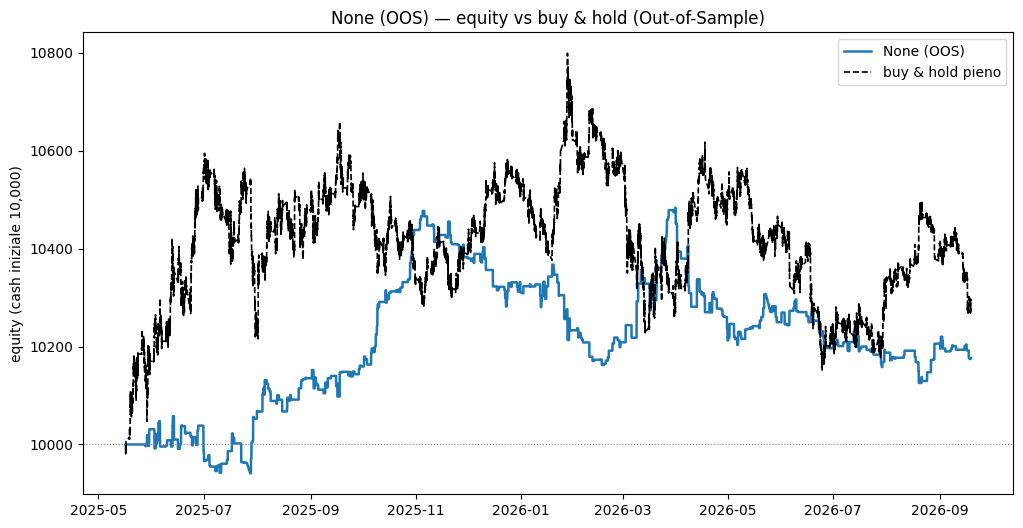

In [35]:
for nome in [*lista_etichette_filtri_oos, None]:
    ax, curva = plot_equity(oos.trades(nome), df_oos, cash=10_000.0,
                            etichetta=f"{nome} (OOS)")